In [1]:
# =========================================================================== #
# Scenario-aggregated optimisation + regret baselines + single-best policies
# - Builds exogenous futures from unique group_<N>=48+ combos in X_ref
# - Optimises per narrative across those futures (aggregate='mean')
# - Computes a FIXED, GLOBAL utopia/worst from X_ref under the same futures
# - Selects ONE representative policy per narrative: the Pareto member that
#   minimises mean range-normalised regret (on its OWN narrative objectives)
# =========================================================================== #

import os
import re
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

# Import utils (ensure utils/ is a package or on sys.path)
from utils.narrative_profiles_optimization_utils import (
    optimise,
    set_estimator_threads,
)

# ---- Paths, model, reference data -------------------------------------------
SCRIPT_DIR_PATH = os.getcwd()
TRAINED_MODELS_DIR = Path(SCRIPT_DIR_PATH) / "trained_models"
MODEL_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.3_without_health_without_consSavings.pkl"

pipeline = joblib.load(MODEL_PATH)

full_df = pd.read_parquet(
    TRAINED_MODELS_DIR / "xgb_pipeline_5.3_without_health_without_consSavings_training_df_cleaned.parquet"
)

feature_cols = list(pipeline.feature_names_in_)
X_ref = full_df[feature_cols].copy()

# Metrics (must match model's predict() column order)
train_metrics = [
    "emission_total",
    "emission_avg_last_five_years",
    "production_total",
    "production_cost_total",
    "technical_cost",
    "air_pollution",
]

# Ensure multi-threaded predict for XGBoost (harmless if not present)
set_estimator_threads(pipeline)

# ---- Exogenous scenarios from unique group_>=48 combinations ----------------
def get_exogenous_group_cols(feature_cols, min_idx=48) -> List[str]:
    """
    Return feature columns that look like group_<num>* where num >= min_idx.
    Matches: group_48, group_48_xxx, group_99_something, etc.
    """
    rx = re.compile(r"^group_(\d+)(?:_|$)")
    out = []
    for c in feature_cols:
        m = rx.match(c)
        if m and int(m.group(1)) >= min_idx:
            out.append(c)
    return out

EXOG_COLS = get_exogenous_group_cols(feature_cols, min_idx=48)
if not EXOG_COLS:
    raise ValueError("No exogenous columns found: expected 'group_<N>' with N >= 48.")

FREE_VARS = [c for c in feature_cols if c not in EXOG_COLS]
if len(FREE_VARS) == 0:
    raise ValueError(
        "All features are exogenous (group_>=48). No decision variables to optimize."
    )

# Build scenarios from unique EXOG_COLS combos present in X_ref
# NOTE: If this set is huge, sample with .head(N)
scenario_rows = (
    X_ref.drop_duplicates(subset=EXOG_COLS, keep="first")
         .reset_index(drop=True)
)

SCENARIOS: List[dict] = []
for _, row in scenario_rows.iterrows():
    SCENARIOS.append({c: float(row[c]) for c in EXOG_COLS})

print(f"[scenarios] Built {len(SCENARIOS)} scenarios from {len(EXOG_COLS)} exogenous cols (group_>=48).")

# Multi-scenario controls
SCENARIO_MODE  = "aggregate"   # "aggregate" or "stack"
SCENARIO_AGG   = "mean"        # "mean" or "worst" (min-space)
SCENARIO_CHUNK = 0             # set >0 to process scenarios in chunks (e.g., 32) for memory control

# ---- Narratives config -------------------------------------------------------
# Keep air_pollution as a BENEFIT (maximize)
narratives_cfg: Dict[str, List[Tuple[str, str]]] = {
    "IndustryEnergyInvestment": [
        ("production_total", "max"),
        ("production_cost_total", "min"),
    ],
    "EmissionsReduction": [
        ("emission_total", "min"),
        ("emission_avg_last_five_years", "min"),
    ],
    "PlaceToLive": [
        ("air_pollution", "max"),
        # ("consumer_savings","max"),
        # ("technical_cost", "min"),
    ],
}

# ---- Helpers ----------------------------------------------------------------
def _ensure_numeric_schema(data_like, feature_cols):
    if isinstance(data_like, pd.DataFrame):
        df = data_like.copy()
    elif isinstance(data_like, pd.Series):
        df = data_like.to_frame().T
    elif isinstance(data_like, (list, tuple)) and data_like and isinstance(data_like[0], dict):
        df = pd.DataFrame(data_like)
    else:
        arr = np.asarray(data_like)
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        elif arr.ndim != 2:
            raise ValueError(f"Unsupported optimiser output shape: {arr.shape}")
        df = pd.DataFrame(arr)
    if list(df.columns) != feature_cols:
        if len(df.columns) == len(feature_cols) and not all(isinstance(c, str) for c in df.columns):
            df.columns = feature_cols
        df = df.reindex(columns=feature_cols)
    if df.empty:
        raise AssertionError("Empty Pareto set after coercion")
    df = df.astype("float32")
    if df.isna().any().any():
        bad = df.columns[df.isna().any()].tolist()
        raise ValueError(f"NaNs present in features: {bad[:10]} ...")
    if not np.isfinite(df.to_numpy()).all():
        raise ValueError("Found ±inf values in features")
    return df

def _clamp_df_to_scenario(X: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    Xc = X.copy()
    for k, v in scenario.items():
        if k in Xc.columns:
            Xc[k] = v
    return Xc

def predict_aggregate_over_scenarios(pipeline, X: pd.DataFrame, scenarios: list, *, agg="mean") -> pd.DataFrame:
    preds = []
    for s in scenarios:
        Xs = _clamp_df_to_scenario(X, s)
        Ys = pd.DataFrame(pipeline.predict(Xs), columns=train_metrics)
        preds.append(Ys)
    if agg == "mean":
        return sum(preds) / len(preds)
    raise NotImplementedError("Only mean aggregation implemented in this driver.")

def split_objs(objs):
    metrics = [m for (m, _) in objs]
    senses  = [s for (_, s) in objs]
    return metrics, senses

def aggregate_regrets(regrets, mode="mean"):
    r = np.asarray(regrets, float)
    if mode == "max": return float(r.max())        # conservative
    if mode == "l2":  return float(np.sqrt((r**2).mean()))  # RMS
    return float(r.mean())

def regret_abs(achieved, utopia, goal):
    return (utopia - achieved) if goal == "max" else (achieved - utopia)

def regret_range(achieved, utopia, worst, goal):
    ra = regret_abs(achieved, utopia, goal)
    span = (utopia - worst) if goal == "max" else (worst - utopia)
    return 0.0 if abs(span) < 1e-12 else ra / span

# ---- Optimise per narrative across SCENARIOS (aggregate-mean) ---------------
pareto_policies: Dict[str, pd.DataFrame] = {}
pareto_scores:   Dict[str, pd.DataFrame] = {}

for name, objs in narratives_cfg.items():
    targets = [m for (m, _) in objs]
    goals   = [s for (_, s) in objs]

    X_p, F_p = optimise(
        pipeline,
        X_ref=X_ref,
        train_targets=train_metrics,
        targets=targets,
        goals=goals,
        n_gen=120,
        pop_size=300,
        n_restarts=1,                  # consider 1-2 restarts (more restarts = slower)
        scenario_sets=SCENARIOS,
        scenario_mode=SCENARIO_MODE,
        scenario_agg=SCENARIO_AGG,
        scenario_chunk=SCENARIO_CHUNK, # 0 or None = no chunking; set e.g. 32 to limit memory
        ensure_threaded_predict=True,  # enable threaded XGBoost predict
    )

    Xp_df  = _ensure_numeric_schema(X_p, feature_cols)
    Ys_agg = predict_aggregate_over_scenarios(pipeline, Xp_df, SCENARIOS, agg="mean")

    pareto_policies[name] = Xp_df
    pareto_scores[name]   = Ys_agg

# ---- FIXED, GLOBAL utopia/worst (from X_ref under SCENARIOS) ----------------
_pred_all_global = predict_aggregate_over_scenarios(pipeline, X_ref, SCENARIOS, agg="mean")

# Gather all metrics and goal directions actually used in narratives
all_obj_specs = {}
for name, objs in narratives_cfg.items():
    for m, s in objs:
        all_obj_specs[m] = s

utopia_global = {
    m: (_pred_all_global[m].max() if g == "max" else _pred_all_global[m].min())
    for m, g in all_obj_specs.items()
}
worst_global = {
    m: (_pred_all_global[m].min() if g == "max" else _pred_all_global[m].max())
    for m, g in all_obj_specs.items()
}

# ---- Select ONE representative "best" policy per narrative ------------------
best_policies_by_narrative: Dict[str, pd.DataFrame] = {}
best_policy_indices: Dict[str, int] = {}

for name, objs in narratives_cfg.items():
    metrics, senses = split_objs(objs)

    Xp_df  = pareto_policies[name]
    Ys_agg = pareto_scores[name]  # predictions per policy (rows), aggregated over SCENARIOS

    # Compute mean range-normalised regret for each Pareto member on THIS narrative's objectives
    regrets_mean = []
    for i in range(len(Xp_df)):
        regs_i = []
        for metric, goal in zip(metrics, senses):
            ach = float(Ys_agg.iloc[i][metric])
            uto = float(utopia_global[metric])
            wst = float(worst_global[metric])
            regs_i.append(regret_range(ach, uto, wst, goal))
        regrets_mean.append(aggregate_regrets(regs_i, mode="mean"))

    idx_best = int(np.argmin(regrets_mean))
    best_policy_indices[name] = idx_best
    best_policies_by_narrative[name] = Xp_df.iloc[[idx_best]].copy()

print("\n[selection] Best policy indices by narrative (0-based):", best_policy_indices)

# ---- Cross-evaluation matrix for the SELECTED policies (global baseline) ----
rows_rng = []
for src_name in narratives_cfg.keys():
    # Predict the single selected policy under the original SCENARIOS
    X_sel = best_policies_by_narrative[src_name]
    Y_sel = predict_aggregate_over_scenarios(
        pipeline, X_sel, SCENARIOS, agg="mean"
    ).iloc[0]

    for eval_name, eval_objs in narratives_cfg.items():
        metrics, senses = split_objs(eval_objs)

        regs = []
        for metric, goal in zip(metrics, senses):
            ach = float(Y_sel[metric])
            uto = float(utopia_global[metric])
            wst = float(worst_global[metric])
            regs.append(regret_range(ach, uto, wst, goal))

        rows_rng.append({
            "Policy": src_name,
            "Evaluated_as": eval_name,
            "Regret": aggregate_regrets(regs, mode="mean")
        })

reg_rng_selected = (
    pd.DataFrame(rows_rng)
      .pivot(index="Policy", columns="Evaluated_as", values="Regret")
      # ensure consistent order of rows/cols
      .reindex(index=list(narratives_cfg.keys()), columns=list(narratives_cfg.keys()))
)

# Optional: hide the self-evaluation diagonal for readability (data kept intact)
reg_rng_display = reg_rng_selected.copy()
for pol in reg_rng_display.index:
    if pol in reg_rng_display.columns:
        reg_rng_display.loc[pol, pol] = np.nan

print("\n### RANGE-NORMALISED regret for SELECTED policies (global baseline, 0–100%)")
display(
    reg_rng_display
        .style
        .format("{:.1%}")
        .background_gradient(cmap="Purples")
)

# ---- Summary across the TWO OTHER narratives (exclude self) -----------------
# Compute mean & worst regret over the TWO OTHER narratives only
other_mean = {}
other_worst = {}

for pol in reg_rng_selected.index:
    mask = reg_rng_selected.columns != pol
    other_vals = reg_rng_selected.loc[pol, mask]
    other_mean[pol] = float(other_vals.mean())
    other_worst[pol] = float(other_vals.max())

summary = (
    pd.DataFrame({
        "WorstRegret_TwoOthers": pd.Series(other_worst),
        "MeanRegret_TwoOthers":  pd.Series(other_mean),
    })
    .reindex(reg_rng_selected.index)
    .round(3)
)

def highlight_min(s: pd.Series):
    is_min = s == s.min()
    return ['background-color: mediumseagreen; color: white' if v else '' for v in is_min]

display(
    summary.style
           .format("{:.1%}")
           .apply(highlight_min, subset=["WorstRegret_TwoOthers", "MeanRegret_TwoOthers"])
           .background_gradient(cmap="OrRd")
           .set_caption(
               "Selected policies — range-normalised regret vs fixed global baseline "
               "(TWO OTHER narratives only)"
           )
)

[scenarios] Built 979 scenarios from 11 exogenous cols (group_>=48).

[selection] Best policy indices by narrative (0-based): {'IndustryEnergyInvestment': 258, 'EmissionsReduction': 6, 'PlaceToLive': 0}

### RANGE-NORMALISED regret for SELECTED policies (global baseline, 0–100%)


Evaluated_as,IndustryEnergyInvestment,EmissionsReduction,PlaceToLive
Policy,,,
IndustryEnergyInvestment,nan%,54.2%,31.6%
EmissionsReduction,70.6%,nan%,8.6%
PlaceToLive,22.9%,14.9%,nan%


,WorstRegret_TwoOthers,MeanRegret_TwoOthers
Policy,,
IndustryEnergyInvestment,54.2%,42.9%
EmissionsReduction,70.6%,39.6%
PlaceToLive,22.9%,18.9%


## Uncertainty analysis 

In [ ]:
# =========================================================================== #
# 2×2 clamped futures on EXP/COST + evaluation of the three SELECTED policies
# - Four SINGLE futures: EXP∈{10th,90th} × COST∈{10th,90th}, others = exogenous medians
# - Uses the SAME fixed global utopia/worst from Chunk 1 for comparability
# - Builds a table where each policy’s value = MEAN regret across the TWO OTHER
#   narratives (NOT its own), per future. The 3-line plot uses that table.
# =========================================================================== #

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Columns of interest
EXP_COL  = "group_51_exports_enfu_pj_fuel"
COST_COL = "group_47_cost_enfu_fuel"

# Ensure present
for col in (EXP_COL, COST_COL):
    if col not in X_ref.columns:
        raise KeyError(f"Required column missing in X_ref: {col}")

# Scenario columns to clamp (all exogenous, plus ensure EXP/COST included)
scenario_cols = sorted(set(EXOG_COLS) | {EXP_COL, COST_COL})

# Quantiles for EXP and COST
q = X_ref[[EXP_COL, COST_COL]].quantile([0.10, 0.90])
exp_lo, exp_hi = float(q.loc[0.10, EXP_COL]), float(q.loc[0.90, EXP_COL])
cost_lo, cost_hi = float(q.loc[0.10, COST_COL]), float(q.loc[0.90, COST_COL])

# Build a SINGLE clamped future for each quadrant; other exogenous = medians
base = X_ref[scenario_cols].median(numeric_only=True).to_dict()
def clamp_future(exp_val, cost_val):
    f = dict(base)
    f[EXP_COL]  = float(exp_val)
    f[COST_COL] = float(cost_val)
    return f

scenario_sets = {
    "EXP↓ COST↓": [clamp_future(exp_lo, cost_lo)],
    "EXP↓ COST↑": [clamp_future(exp_lo, cost_hi)],
    "EXP↑ COST↓": [clamp_future(exp_hi, cost_lo)],
    "EXP↑ COST↑": [clamp_future(exp_hi, cost_hi)],
}
labels = list(scenario_sets.keys())  # preserve order

# ---- Helpers ----------------------------------------------------------------
def split_objs(objs):
    metrics = [m for (m, _) in objs]
    senses  = [s for (_, s) in objs]
    return metrics, senses

def regret_abs(achieved, utopia, goal):
    return (utopia - achieved) if goal == "max" else (achieved - utopia)

def regret_range(achieved, utopia, worst, goal):
    ra = regret_abs(achieved, utopia, goal)
    span = (utopia - worst) if goal == "max" else (worst - utopia)
    return 0.0 if abs(span) < 1e-12 else ra / span

def aggregate_regrets(regrets, mode="mean"):
    r = np.asarray(regrets, float)
    if mode == "max": return float(r.max())
    if mode == "l2":  return float(np.sqrt((r**2).mean()))
    return float(r.mean())

def eval_policy_regret_as(policy_df: pd.DataFrame, eval_name: str, scenario_subset: list) -> float:
    """Mean range-normalised regret for `policy_df` when evaluated AS `eval_name`
       (averaged across that narrative's objectives), under `scenario_subset`."""
    metrics, senses = split_objs(narratives_cfg[eval_name])
    Y = predict_aggregate_over_scenarios(pipeline, policy_df, scenario_subset, agg="mean").iloc[0]
    regs = []
    for metric, goal in zip(metrics, senses):
        ach = float(Y[metric])
        uto = float(utopia_global[metric])  # FIXED global baseline from Chunk 1
        wst = float(worst_global[metric])
        regs.append(regret_range(ach, uto, wst, goal))
    return aggregate_regrets(regs, mode="mean")

# ---- Build table: MEAN regret across the TWO OTHER narratives ----------------
records = []
policy_names = list(best_policies_by_narrative.keys())

for label in labels:
    subset = scenario_sets[label]
    for policy_name in policy_names:
        policy_df = best_policies_by_narrative[policy_name]
        # Evaluate against the OTHER narratives only
        other_names = [n for n in policy_names if n != policy_name]
        other_vals = [eval_policy_regret_as(policy_df, n, subset) for n in other_names]
        cross_mean = float(np.mean(other_vals)) if len(other_vals) > 0 else np.nan

        # (Optional) keep the individual other-narrative values if needed later
        row = {"Scenario": label, "Policy": policy_name, "CrossNarrativesMeanRegret": cross_mean}
        for n, v in zip(other_names, other_vals):
            row[f"Regret_as_{n}"] = v
        records.append(row)

cross_regret_df = pd.DataFrame(records)

# Pivot for display/plot: rows = scenarios, cols = policies, vals = mean regret across the OTHER narratives
cross_regret_pivot = (
    cross_regret_df
        .pivot(index="Scenario", columns="Policy", values="CrossNarrativesMeanRegret")
        .reindex(labels)
)

display(
    cross_regret_pivot
        .style.format("{:.1%}")
        .background_gradient(cmap="Purples")
        .set_caption("Mean regret across the TWO OTHER narratives for each selected policy (fixed global baseline)")
)

# (Optional) also show the per-other-narrative breakdown table
cols_show = ["Scenario", "Policy"] + [c for c in cross_regret_df.columns if c.startswith("Regret_as_")]
display(
    cross_regret_df[cols_show]
        .sort_values(["Scenario", "Policy"])
        .style.format({c: "{:.1%}" for c in cols_show if c.startswith("Regret_as_")})
        .set_caption("Per-other-narrative regret components (for reference)")
)



Policy,EmissionsReduction,IndustryEnergyInvestment,PlaceToLive
Scenario,,,
EXP↓ COST↓,39.0%,28.9%,10.4%
EXP↓ COST↑,39.2%,29.1%,10.4%
EXP↑ COST↓,41.4%,54.3%,26.6%
EXP↑ COST↑,41.6%,54.5%,26.6%


,Scenario,Policy,Regret_as_EmissionsReduction,Regret_as_PlaceToLive,Regret_as_IndustryEnergyInvestment
10,EXP↑ COST↑,EmissionsReduction,nan%,12.6%,70.7%
9,EXP↑ COST↑,IndustryEnergyInvestment,70.7%,38.2%,nan%
11,EXP↑ COST↑,PlaceToLive,31.1%,nan%,22.2%
7,EXP↑ COST↓,EmissionsReduction,nan%,12.4%,70.4%
6,EXP↑ COST↓,IndustryEnergyInvestment,70.5%,38.1%,nan%
8,EXP↑ COST↓,PlaceToLive,31.2%,nan%,22.0%
4,EXP↓ COST↑,EmissionsReduction,nan%,7.7%,70.6%
3,EXP↓ COST↑,IndustryEnergyInvestment,33.7%,24.6%,nan%
5,EXP↓ COST↑,PlaceToLive,-1.2%,nan%,22.1%
1,EXP↓ COST↓,EmissionsReduction,nan%,7.7%,70.3%


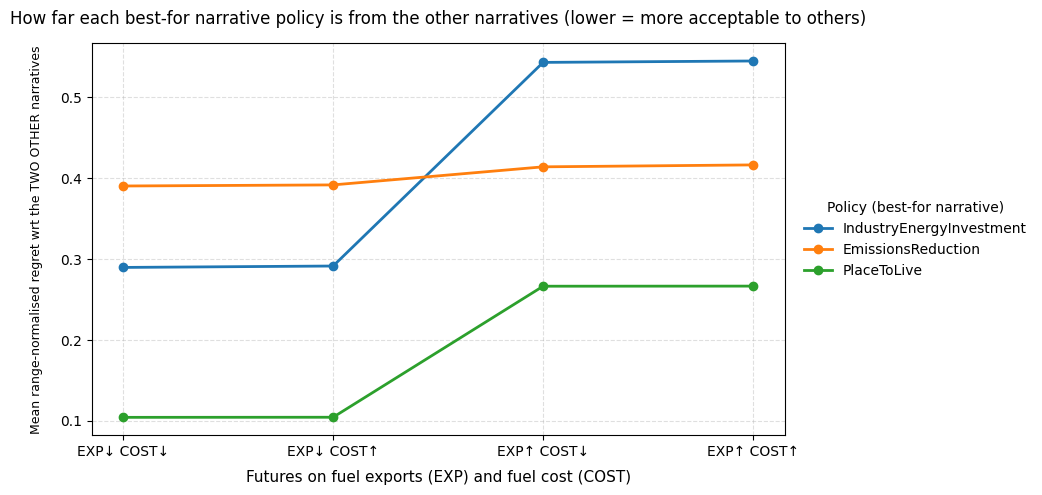

In [3]:
# ---- 3-line plot using the mean OTHER-narratives regret (clean layout) -----
fig, ax = plt.subplots(figsize=(10.5, 5.6))
x = np.arange(len(labels))

for policy_name in policy_names:
    y = cross_regret_pivot[policy_name].values.astype(float)
    ax.plot(x, y, marker="o", linewidth=2, label=policy_name)

ax.set_xticks(x, labels)
ax.set_xlabel(
    "Futures on fuel exports (EXP) and fuel cost (COST)",
    fontsize=11, labelpad=8
)
ax.set_ylabel(
    "Mean range-normalised regret wrt the TWO OTHER narratives",
    fontsize=9, labelpad=12
)
ax.set_title(
    "How far each best-for narrative policy is from the other narratives (lower = more acceptable to others)",
    fontsize=12, pad=14
)
ax.tick_params(axis="both", labelsize=10)
ax.grid(True, linestyle="--", alpha=0.4)

# Put the legend outside the axes on the right, and add right margin for it
ax.legend(
    title="Policy (best-for narrative)",
    fontsize=10, title_fontsize=10,
    loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0,
    frameon=False
)

# Extra whitespace so long labels don’t collide
fig.subplots_adjust(left=0.12, right=0.78, top=0.88, bottom=0.18)

plt.show()
